In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, pandas as pd, matplotlib.pyplot as plt, numpy as np, seaborn as sns, glob
from pynwb import NWBHDF5IO
from pathlib import Path
from convnwb.io import load_nwbfile
from scipy.ndimage import gaussian_filter1d

In [74]:
sess_file = glob.glob('../../data/000623/sub-CS54/*.nwb')[0]
nwbfile, io = load_nwbfile(os.path.basename(sess_file), os.path.dirname(sess_file), return_io=True)
nwbfile

Data type,int64
Shape,"(603,)"
Array size,4.71 KiB
Chunk shape,None
Compression,None
Compression opts,None
Compression ratio,1.0
Data type,float64
Shape,"(603,)"
Array size,4.71 KiB
Chunk shape,None


## cleaning

In [75]:
df_trials = nwbfile.trials.to_dataframe()

enc_start, enc_stop = 0, 475 # true end of movie

# baseline = time between movie end and recognition task beginning
base_start, base_stop = int(df_trials['stop_time'].iloc[0]), int(df_trials['start_time'].iloc[1])
base_dur = base_stop - base_start
print(f'base_start, base_stop, base_dur: {base_start}, {base_stop}, {base_dur}')

df_trials.head()

base_start, base_stop, base_dur: 478, 594, 116


,start_time,stop_time,stim_phase,stimulus_file,response_correct,response_confidence,actual_response,response_time
id,,,,,,,,
0,0.000000,478.838495,encoding,bd_movie,NaN,NaN,NaN,478.838495
1,594.363199,625.681342,recognition,new012.png,0.0,1.0,4.0,625.681342
2,626.731467,636.991181,recognition,new027.png,0.0,2.0,5.0,636.991181
3,638.035619,650.066051,recognition,new029.png,1.0,3.0,1.0,650.066051
4,651.112738,664.651733,recognition,new004.png,1.0,1.0,3.0,664.651733


In [76]:
df_units = nwbfile.units.to_dataframe()
df_units = df_units[['unit_id_session', 'electrode_id', 'spike_times']]
df_units.head()

,unit_id_session,electrode_id,spike_times
id,,,
0,P54CS_R1_9_1_1755_8,8,"[0.65082775, 2.555983, 5.261982, 9.07388725, 9..."
1,P54CS_R1_9_2_1783_8,8,"[2.447483, 2.52332675, 2.552733, 3.30388925, 4..."
2,P54CS_R1_9_3_1786_8,8,"[0.56282775, 1.065359, 1.568859, 2.2772965, 2...."
3,P54CS_R1_10_1_3992_8,9,"[0.09282775, 0.14764025, 0.2529215, 0.4700465,..."
4,P54CS_R1_10_2_3997_8,9,"[0.37314025, 0.44551525, 1.151859, 1.52357775,..."


In [77]:
df_electrodes = nwbfile.electrodes.to_dataframe()
df_electrodes.head()

,location,group,group_name,origchannel,pairwise_distances,origchannel_name,x,y,z
id,,,,,,,,,
0,Left ACC,Neuralynx-Atlas-microwire-1 pynwb.ecephys.Elec...,Neuralynx-Atlas-microwire-1,micro-1,NA,LACC1,-3.85,29.02,23.7
1,Left ACC,Neuralynx-Atlas-microwire-2 pynwb.ecephys.Elec...,Neuralynx-Atlas-microwire-2,micro-2,NA,LACC2,-3.85,29.02,23.7
2,Left ACC,Neuralynx-Atlas-microwire-3 pynwb.ecephys.Elec...,Neuralynx-Atlas-microwire-3,micro-3,NA,LACC3,-3.85,29.02,23.7
3,Left ACC,Neuralynx-Atlas-microwire-4 pynwb.ecephys.Elec...,Neuralynx-Atlas-microwire-4,micro-4,NA,LACC4,-3.85,29.02,23.7
4,Left ACC,Neuralynx-Atlas-microwire-5 pynwb.ecephys.Elec...,Neuralynx-Atlas-microwire-5,micro-5,NA,LACC5,-3.85,29.02,23.7


In [78]:
# Replace unit_id in df_units with the corresponding location from electrodes_df
df_clean = df_units.copy()
df_clean['electrode_id'] = df_units['electrode_id'].map(df_electrodes['location'])
df_clean['electrode_id'] = df_clean['electrode_id'].str.split().str[-1]
df_clean = df_clean.rename(columns={'electrode_id': 'region'})

df_clean = df_clean.sort_values(by='region').reset_index(drop=True)

# rename region vals as region + index, for e.g., ACC_0, ACC_1, amygdala_3, etc.
df_clean['region'] = df_clean['region'] + '_neur' + df_clean.index.astype(str)
df_clean.drop(columns=['unit_id_session'], inplace=True)

print(len(df_clean))
df_clean.head(10)

123


,region,spike_times
0,ACC_neur0,"[0.354859, 1.358859, 2.38720275, 2.724983, 5.0..."
1,ACC_neur1,"[0.11889025, 0.150359, 1.10526525, 1.41520275,..."
2,ACC_neur2,"[0.5274215, 0.548109, 0.8279215, 0.876234, 0.9..."
3,ACC_neur3,"[0.18764025, 0.47132775, 0.702734, 1.0887965, ..."
4,amygdala_neur4,"[0.84014025, 0.84401525, 1.41314025, 1.4807027..."
5,amygdala_neur5,"[0.0037965, 0.01882775, 0.28232775, 0.33807775..."
6,amygdala_neur6,"[0.163734, 0.222234, 0.2442965, 0.3030465, 0.6..."
7,amygdala_neur7,"[0.307109, 0.59564025, 0.607359, 1.152984, 1.1..."
8,amygdala_neur8,"[0.16970275, 0.3142965, 0.3301715, 0.620359, 0..."
9,amygdala_neur9,"[0.29070275, 0.49045275, 1.5324215, 2.289859, ..."


## authors noted periods of 16s with missing data. drop such neurons.

In [79]:
df_filtered = df_clean.copy()

df_filtered['enc_spike_times'] = None
df_filtered['base_FR_mean'] = np.nan
df_filtered['base_FR_std'] = np.nan

# to be used for baseline sd calculation
base_bins = np.arange(base_start, base_stop + 1)

for id, neur in df_clean.iterrows():

    spike_times = neur['spike_times']

    # encoding spikes
    enc_spike_times = spike_times[spike_times < enc_stop]

    # filter out neurons with more than 16 seconds between spikes
    time_diffs = np.diff(enc_spike_times)
    if np.max(time_diffs) > 16:
        df_filtered.drop(id, inplace=True)
        continue

    # baseline spikes
    base_spike_times = spike_times[(spike_times >= base_start) & (spike_times < base_stop)]

    # if <2 baseline spikes, cannot calculate sd, so drop
    if len(base_spike_times) < 2:
        df_filtered.drop(id, inplace=True)
        continue
    
    base_FR_mean = len(base_spike_times) / base_dur

    counts_per_bin, _ = np.histogram(base_spike_times, bins=base_bins)
    base_FR_std = np.std(counts_per_bin)  # or counts_per_bin / 1.0 if you want in Hz

    df_filtered.at[id, 'base_FR_mean'] = base_FR_mean
    df_filtered.at[id, 'base_FR_std'] = base_FR_std
    df_filtered.at[id, 'enc_spike_times'] = enc_spike_times

df_filtered.drop(columns=['spike_times'], inplace=True)
df_filtered.reset_index(drop=True, inplace=True)

print(len(df_filtered))
df_filtered.head()

91


,region,enc_spike_times,base_FR_mean,base_FR_std
0,ACC_neur0,"[0.354859, 1.358859, 2.38720275, 2.724983, 5.0...",1.543103,1.610270
1,ACC_neur1,"[0.11889025, 0.150359, 1.10526525, 1.41520275,...",2.051724,1.794843
2,ACC_neur2,"[0.5274215, 0.548109, 0.8279215, 0.876234, 0.9...",2.517241,2.048897
3,ACC_neur3,"[0.18764025, 0.47132775, 0.702734, 1.0887965, ...",1.560345,1.763073
4,amygdala_neur4,"[0.84014025, 0.84401525, 1.41314025, 1.4807027...",0.318966,0.749703


## convert to spike train

In [80]:
enc_bins = np.arange(enc_start, enc_stop + 1)
n_neurs = len(df_filtered)

neur_by_time = np.zeros((n_neurs, enc_stop-enc_start))

for id, neur in df_filtered.iterrows():

    spike_times = neur['enc_spike_times']

    # get counts per bin
    spike_counts, _ = np.histogram(spike_times, bins=enc_bins)

    # norm by bin size
    spike_counts = spike_counts / np.diff(enc_bins)

    # norm by baseline activity
    spike_counts = (spike_counts - neur['base_FR_mean']) / neur['base_FR_std']
    
    neur_by_time[id, :] = spike_counts

time_by_neur = neur_by_time.T
print(time_by_neur.shape)

df_time_by_neur = pd.DataFrame(time_by_neur, columns=df_filtered['region'].tolist())
df_time_by_neur.to_csv('../outputs/csvs/time_by_neur_P54CS_R1.csv', index=False)
df_time_by_neur.head()

(475, 91)


,ACC_neur0,ACC_neur1,ACC_neur2,ACC_neur3,amygdala_neur4,amygdala_neur5,amygdala_neur6,amygdala_neur7,amygdala_neur8,amygdala_neur9,...,vmPFC_neur105,vmPFC_neur106,vmPFC_neur107,vmPFC_neur109,vmPFC_neur112,vmPFC_neur113,vmPFC_neur114,vmPFC_neur120,vmPFC_neur121,vmPFC_neur122
0,-0.337275,-0.028818,1.211754,0.816560,2.242268,3.851317,2.267450,-0.002883,0.217788,1.396751,...,0.526687,-1.409753,3.395522,2.224977,2.416434,0.529234,1.426298,-0.786146,1.330786,-1.367743
1,-0.337275,1.642637,0.723686,-0.317823,3.576130,2.714541,0.853341,1.000490,-0.062917,0.414793,...,-0.801480,1.632690,0.781271,-0.632189,2.416434,1.260082,-0.736455,-0.786146,0.000000,0.428387
2,0.283739,-0.028818,2.187889,0.816560,2.242268,2.335616,1.206868,1.000490,-0.062917,2.378709,...,0.526687,-0.649142,0.781271,1.272588,-0.358876,0.529234,2.507675,1.113707,0.000000,0.428387
3,-0.958289,-0.585970,0.723686,0.249369,4.909992,1.956691,0.853341,1.000490,-0.343621,3.360668,...,-0.801480,0.111469,-0.961564,0.320200,-0.358876,6.376013,-0.736455,-0.786146,0.000000,0.428387
4,-0.958289,0.528334,0.235619,-0.317823,-0.425456,1.577766,1.560396,1.669406,-0.905031,-0.567166,...,-0.801480,-1.409753,0.781271,0.320200,2.416434,1.990929,-0.736455,0.163780,0.665393,-0.170323


## plot neur_by_time

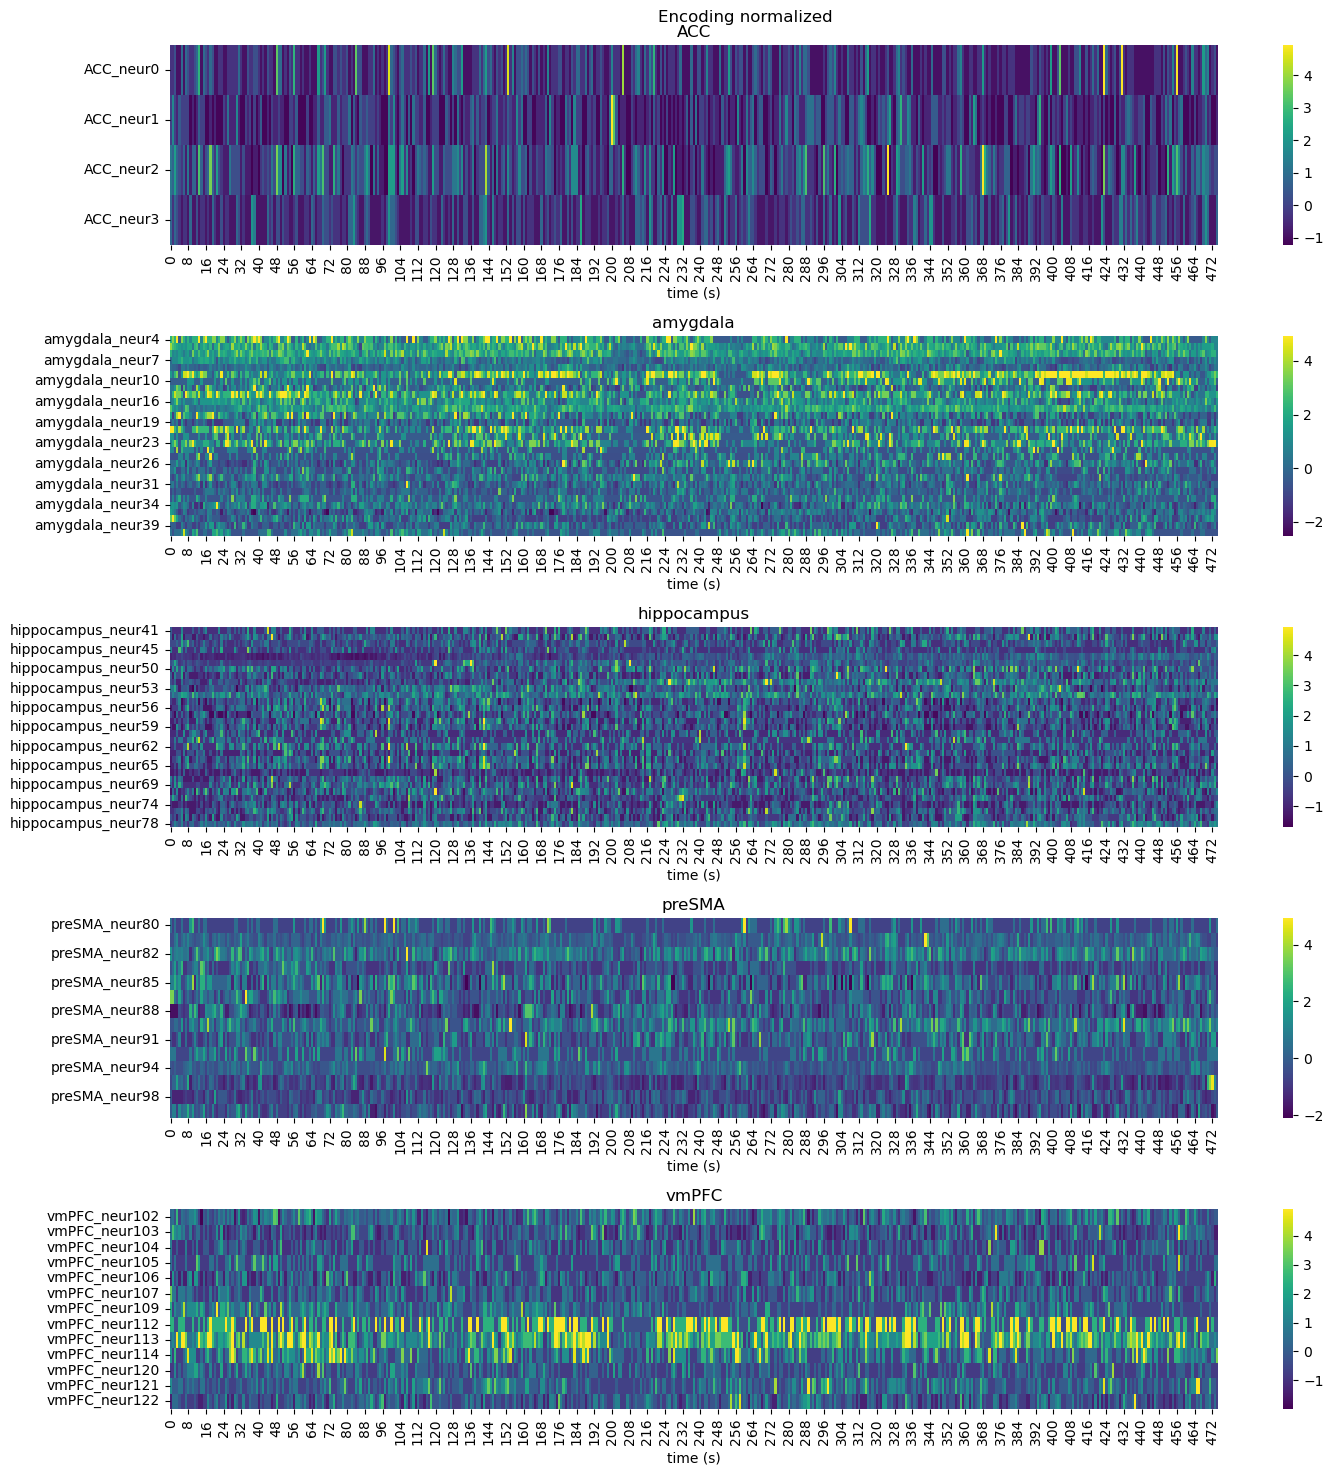

In [ ]:
# get all region names from neuron col names
neuron_cols = [col for col in df_time_by_neur.columns if '_neur' in col]
regions = sorted(set([col.split('_neur')[0] for col in neuron_cols]))

fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

for region in regions:

    # grab columns for the current region
    region_cols = [col for col in df_time_by_neur.columns if col.startswith(region)]
    df_neur_by_time = df_time_by_neur[region_cols].T

    sns.heatmap(df_neur_by_time, cmap='viridis', cbar=True, ax=axs[ax], vmax = np.percentile(df_neur_by_time.values, 99))
    axs[ax].set(xlabel='time (s)', title = region)
    ax += 1

plt.suptitle('Encoding normalized')

plt.tight_layout()
plt.show()

## loads & combine csvs

In [83]:
df_manual_annots = pd.read_csv('../input_data/csvs/manual_annots.csv')
df_manual_annots = df_manual_annots.fillna(0) # replace NaNs with 0
df_manual_annots.head()

,frame,gun_with_protagonist,gun_closeup,protagonist,misc_char,mom,uncle,dad,unrevealed_object_protag_looks_at,bullets,annoying_kid,maid
0,11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,12,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,13,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,14,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,15,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
df_time_by_neur = pd.read_csv(f'../outputs/csvs/time_by_neur_P54CS_R1.csv')
df_time_by_neur.head()

,ACC_neur0,ACC_neur1,ACC_neur2,ACC_neur3,amygdala_neur4,amygdala_neur5,amygdala_neur6,amygdala_neur7,amygdala_neur8,amygdala_neur9,...,vmPFC_neur105,vmPFC_neur106,vmPFC_neur107,vmPFC_neur109,vmPFC_neur112,vmPFC_neur113,vmPFC_neur114,vmPFC_neur120,vmPFC_neur121,vmPFC_neur122
0,-0.337275,-0.028818,1.211754,0.816560,2.242268,3.851317,2.267450,-0.002883,0.217788,1.396751,...,0.526687,-1.409753,3.395522,2.224977,2.416434,0.529234,1.426298,-0.786146,1.330786,-1.367743
1,-0.337275,1.642637,0.723686,-0.317823,3.576130,2.714541,0.853341,1.000490,-0.062917,0.414793,...,-0.801480,1.632690,0.781271,-0.632189,2.416434,1.260082,-0.736455,-0.786146,0.000000,0.428387
2,0.283739,-0.028818,2.187889,0.816560,2.242268,2.335616,1.206868,1.000490,-0.062917,2.378709,...,0.526687,-0.649142,0.781271,1.272588,-0.358876,0.529234,2.507675,1.113707,0.000000,0.428387
3,-0.958289,-0.585970,0.723686,0.249369,4.909992,1.956691,0.853341,1.000490,-0.343621,3.360668,...,-0.801480,0.111469,-0.961564,0.320200,-0.358876,6.376013,-0.736455,-0.786146,0.000000,0.428387
4,-0.958289,0.528334,0.235619,-0.317823,-0.425456,1.577766,1.560396,1.669406,-0.905031,-0.567166,...,-0.801480,-1.409753,0.781271,0.320200,2.416434,1.990929,-0.736455,0.163780,0.665393,-0.170323


In [86]:
assert df_manual_annots.shape[0] == df_time_by_neur.shape[0], "dimension mismatch!"
df_combined = pd.concat([df_manual_annots.reset_index(drop=True), df_time_by_neur.reset_index(drop=True)], axis=1)

print(df_combined.shape)
df_combined.to_csv(f'../outputs/gerald/FRs_and_gaze_P54CS_R1.csv', index=False)
df_combined.head()

(475, 103)


,frame,gun_with_protagonist,gun_closeup,protagonist,misc_char,mom,uncle,dad,unrevealed_object_protag_looks_at,bullets,...,vmPFC_neur105,vmPFC_neur106,vmPFC_neur107,vmPFC_neur109,vmPFC_neur112,vmPFC_neur113,vmPFC_neur114,vmPFC_neur120,vmPFC_neur121,vmPFC_neur122
0,11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.526687,-1.409753,3.395522,2.224977,2.416434,0.529234,1.426298,-0.786146,1.330786,-1.367743
1,12,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.801480,1.632690,0.781271,-0.632189,2.416434,1.260082,-0.736455,-0.786146,0.000000,0.428387
2,13,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.526687,-0.649142,0.781271,1.272588,-0.358876,0.529234,2.507675,1.113707,0.000000,0.428387
3,14,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.801480,0.111469,-0.961564,0.320200,-0.358876,6.376013,-0.736455,-0.786146,0.000000,0.428387
4,15,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.801480,-1.409753,0.781271,0.320200,2.416434,1.990929,-0.736455,0.163780,0.665393,-0.170323


## plot

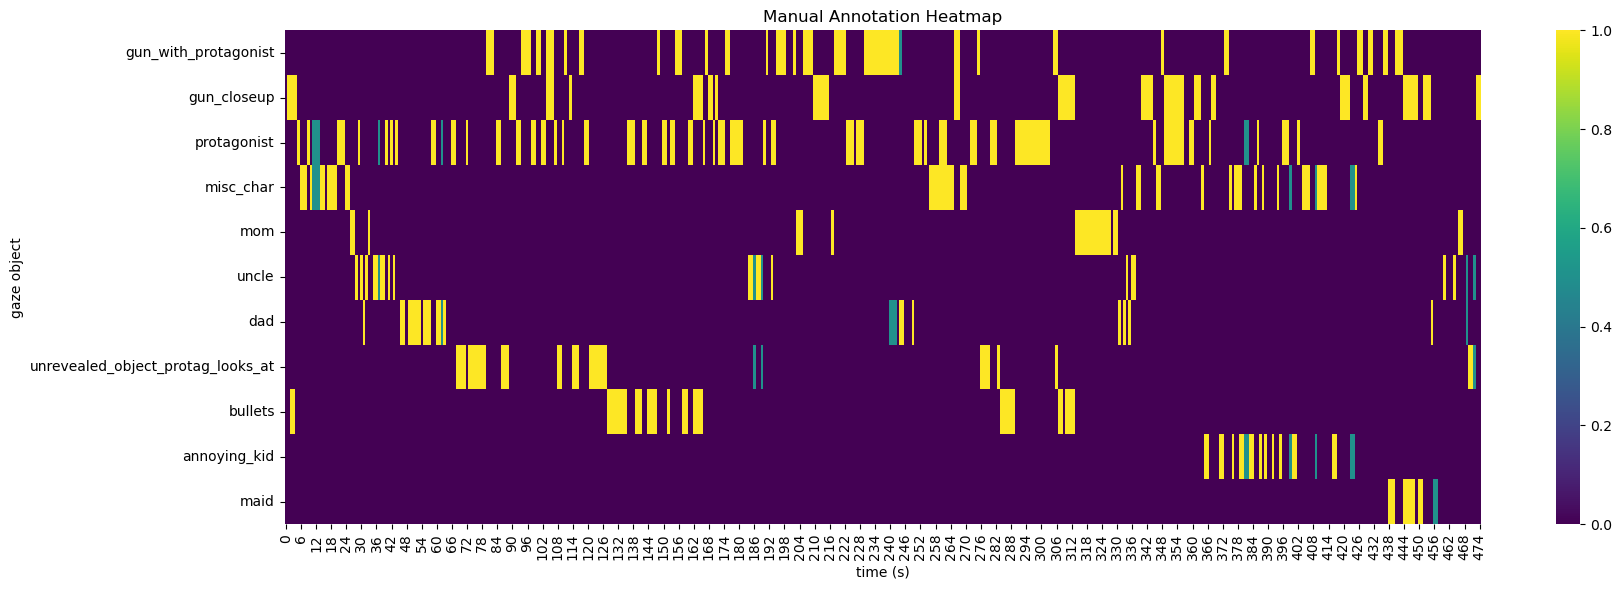

In [87]:
plt.figure(figsize=(18, 6))
gaze_cols = [col for col in df_combined.columns if 'neur' not in col and 'frame' not in col]
sns.heatmap(df_combined[gaze_cols].T, cmap='viridis', cbar=True)
plt.xlabel('time (s)')
plt.ylabel('gaze object')
plt.title('Manual Annotation Heatmap')
plt.tight_layout()
plt.show()


## plotting neur_by_time for session P54CS_R1

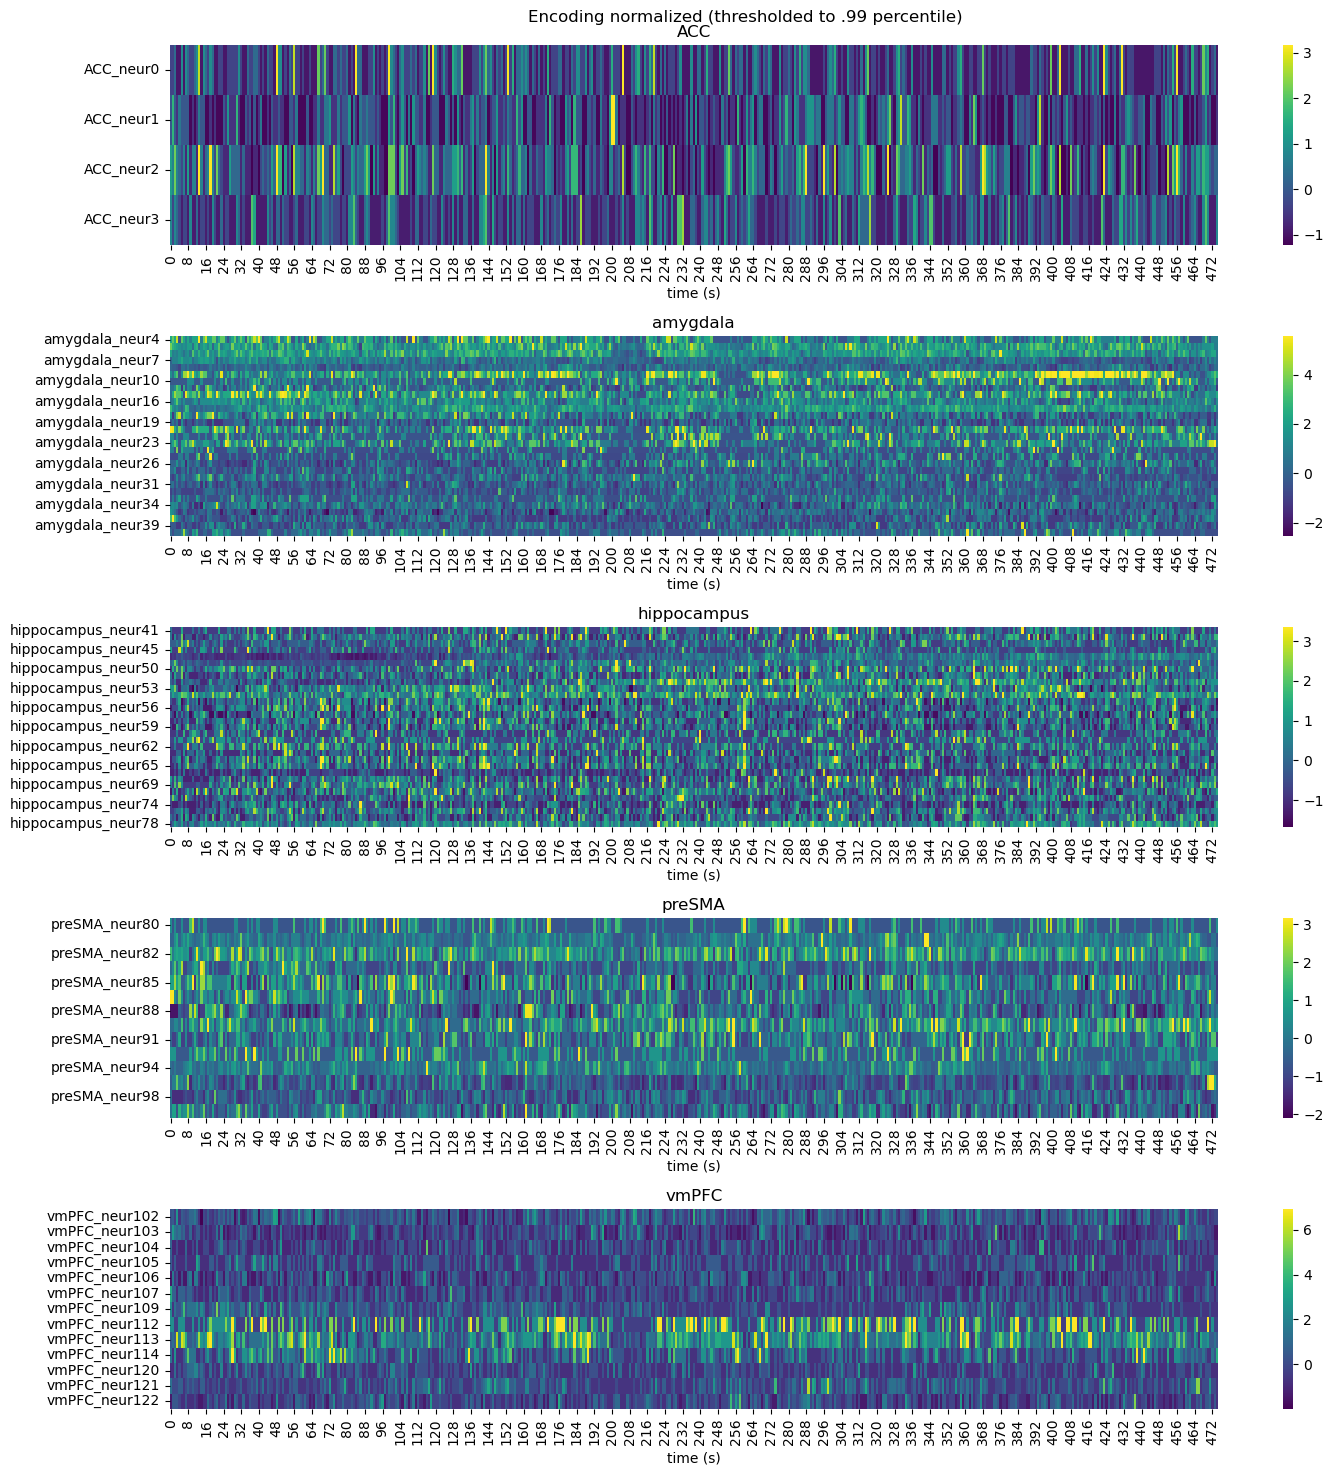

In [94]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

# Get all region names from neuron col names
neuron_cols = [col for col in df_combined.columns if '_neur' in col]
regions = sorted(set([col.split('_neur')[0] for col in neuron_cols]))

for region in regions:

    region_cols = [col for col in df_time_by_neur.columns if col.startswith(region)]
    neur_by_time = df_time_by_neur[region_cols].T  # neurons × time
    sns.heatmap(neur_by_time, cmap='viridis', cbar=True, ax=axs[ax], vmax=np.percentile(neur_by_time.values, 99))
    axs[ax].set(xlabel='time (s)', title = region)
    ax += 1

plt.suptitle('Encoding normalized (thresholded to .99 percentile)')
plt.tight_layout()
plt.show()

## check baseline activity

In [47]:
df_filtered = df_clean.copy()

df_filtered['enc_spike_times'] = None
df_filtered['base_spike_times'] = None
df_filtered['base_FR_mean'] = np.nan
df_filtered['base_FR_std'] = np.nan

# to be used for baseline sd calculation
base_bins = np.arange(base_start, base_stop + 1)

for id, neur in df_clean.iterrows():

    spike_times = neur['spike_times']

    # encoding spikes
    enc_spike_times = spike_times[spike_times < enc_stop]

    # filter out neurons with more than 16 seconds between spikes
    time_diffs = np.diff(enc_spike_times)
    if np.max(time_diffs) > 16:
        df_filtered.drop(id, inplace=True)
        continue

    # baseline spikes
    base_spike_times = spike_times[(spike_times >= base_start) & (spike_times < base_stop)]

    # if <2 baseline spikes, cannot calculate sd, so drop
    if len(base_spike_times) < 2:
        df_filtered.drop(id, inplace=True)
        continue
    
    base_FR_mean = len(base_spike_times) / base_dur

    counts_per_bin, _ = np.histogram(base_spike_times, bins=base_bins)
    base_FR_std = np.std(counts_per_bin)  # or counts_per_bin / 1.0 if you want in Hz

    df_filtered.at[id, 'base_FR_mean'] = base_FR_mean
    df_filtered.at[id, 'base_FR_std'] = base_FR_std
    df_filtered.at[id, 'enc_spike_times'] = enc_spike_times
    df_filtered.at[id, 'base_spike_times'] = base_spike_times


df_filtered.drop(columns=['spike_times'], inplace=True)
df_filtered.reset_index(drop=True, inplace=True)

print(len(df_filtered))
df_filtered.head()

91


,region,enc_spike_times,base_spike_times,base_FR_mean,base_FR_std
0,ACC_neur0,"[0.354859, 1.358859, 2.38720275, 2.724983, 5.0...","[479.06313575, 480.08357325, 480.1886045, 481....",1.543103,1.610270
1,ACC_neur1,"[0.11889025, 0.150359, 1.10526525, 1.41520275,...","[478.1156055, 478.204417, 478.26119825, 479.02...",2.051724,1.794843
2,ACC_neur2,"[0.5274215, 0.548109, 0.8279215, 0.876234, 0.9...","[478.015043, 478.0501055, 478.17044825, 478.98...",2.517241,2.048897
3,ACC_neur3,"[0.18764025, 0.47132775, 0.702734, 1.0887965, ...","[478.03994925, 478.12751175, 478.16344825, 478...",1.560345,1.763073
4,amygdala_neur4,"[0.84014025, 0.84401525, 1.41314025, 1.4807027...","[480.31963575, 481.01244725, 481.88732225, 482...",0.318966,0.749703


## convert to spike train

In [48]:
base_bins = np.arange(base_start, base_stop + 1)
n_neurs = len(df_filtered)

neur_by_time = np.zeros((n_neurs, base_stop-base_start))

for id, neur in df_filtered.iterrows():

    spike_times = neur['base_spike_times']

    # get counts per bin
    spike_counts, _ = np.histogram(spike_times, bins=base_bins)

    # norm by bin size
    spike_counts = spike_counts / np.diff(base_bins)

    neur_by_time[id, :] = spike_counts

time_by_neur = neur_by_time.T
print(time_by_neur.shape)

df_final = pd.DataFrame(time_by_neur, columns=df_filtered['region'].tolist())
df_final.head()

(116, 91)


,ACC_neur0,ACC_neur1,ACC_neur2,ACC_neur3,amygdala_neur4,amygdala_neur5,amygdala_neur6,amygdala_neur7,amygdala_neur8,amygdala_neur9,...,vmPFC_neur105,vmPFC_neur106,vmPFC_neur107,vmPFC_neur109,vmPFC_neur112,vmPFC_neur113,vmPFC_neur114,vmPFC_neur120,vmPFC_neur121,vmPFC_neur122
0,0.0,3.0,4.0,8.0,0.0,5.0,10.0,5.0,8.0,1.0,...,1.0,3.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0
1,1.0,2.0,3.0,1.0,0.0,9.0,9.0,2.0,8.0,1.0,...,1.0,0.0,1.0,0.0,2.0,4.0,1.0,0.0,0.0,2.0
2,2.0,6.0,3.0,5.0,1.0,10.0,8.0,4.0,7.0,2.0,...,0.0,0.0,1.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,2.0,9.0,6.0,2.0,12.0,4.0,...,1.0,2.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,3.0
4,2.0,4.0,0.0,1.0,1.0,5.0,10.0,3.0,8.0,2.0,...,0.0,0.0,0.0,0.0,1.0,4.0,1.0,2.0,0.0,2.0


In [49]:
base_bins = np.arange(base_start, base_stop + 1)
n_neurs = len(df_filtered)

neur_by_time = np.zeros((n_neurs, base_stop-base_start))

for id, neur in df_filtered.iterrows():

    spike_times = neur['base_spike_times']

    # get counts per bin
    spike_counts, _ = np.histogram(spike_times, bins=base_bins)

    # norm by bin size
    spike_counts = spike_counts / np.diff(base_bins)

    neur_by_time[id, :] = spike_counts

time_by_neur = neur_by_time.T
print(time_by_neur.shape)

df_final = pd.DataFrame(time_by_neur, columns=df_filtered['region'].tolist())
df_final.head()

(116, 91)


,ACC_neur0,ACC_neur1,ACC_neur2,ACC_neur3,amygdala_neur4,amygdala_neur5,amygdala_neur6,amygdala_neur7,amygdala_neur8,amygdala_neur9,...,vmPFC_neur105,vmPFC_neur106,vmPFC_neur107,vmPFC_neur109,vmPFC_neur112,vmPFC_neur113,vmPFC_neur114,vmPFC_neur120,vmPFC_neur121,vmPFC_neur122
0,0.0,3.0,4.0,8.0,0.0,5.0,10.0,5.0,8.0,1.0,...,1.0,3.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0
1,1.0,2.0,3.0,1.0,0.0,9.0,9.0,2.0,8.0,1.0,...,1.0,0.0,1.0,0.0,2.0,4.0,1.0,0.0,0.0,2.0
2,2.0,6.0,3.0,5.0,1.0,10.0,8.0,4.0,7.0,2.0,...,0.0,0.0,1.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,2.0,9.0,6.0,2.0,12.0,4.0,...,1.0,2.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,3.0
4,2.0,4.0,0.0,1.0,1.0,5.0,10.0,3.0,8.0,2.0,...,0.0,0.0,0.0,0.0,1.0,4.0,1.0,2.0,0.0,2.0


## plot

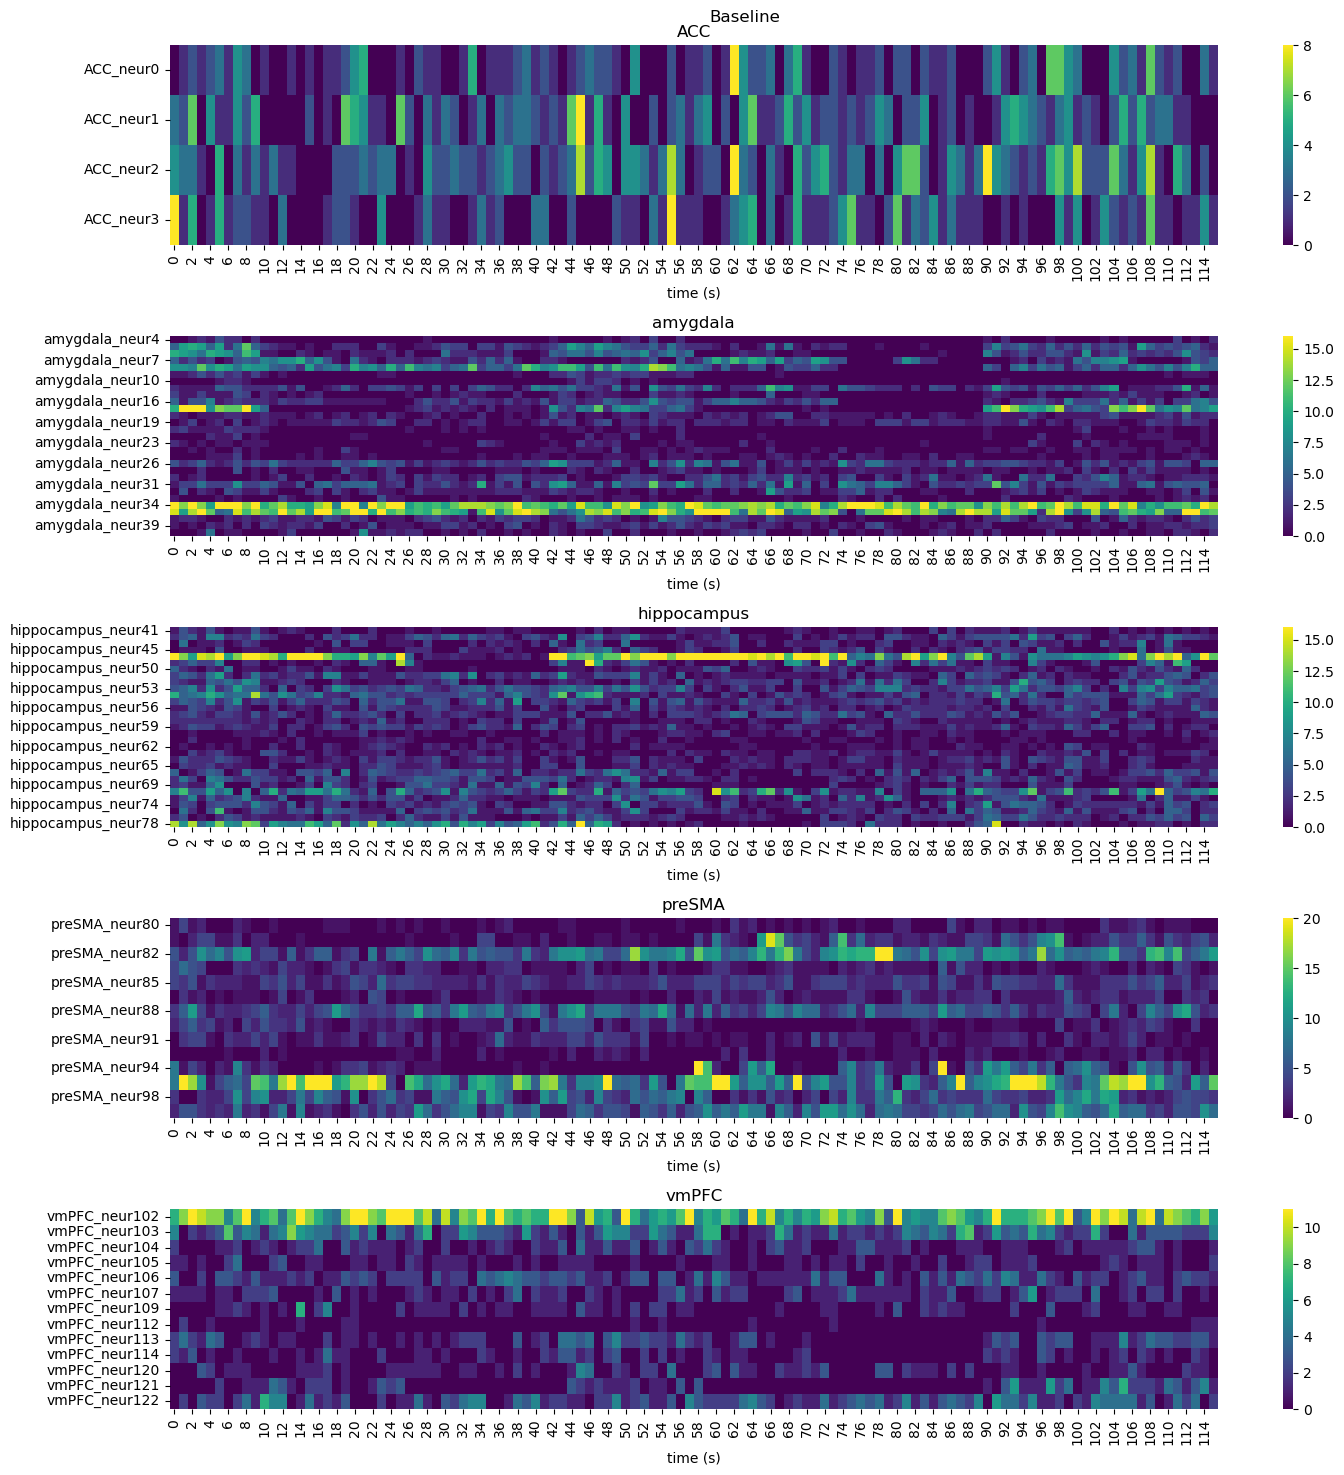

In [51]:
# get all region names from neuron col names
neuron_cols = [col for col in df_final.columns if '_neur' in col]
regions = sorted(set([col.split('_neur')[0] for col in neuron_cols]))

fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

for region in regions:

    # grab columns for the current region
    region_cols = [col for col in df_final.columns if col.startswith(region)]
    df_time_by_neur = df_final[region_cols]

    sns.heatmap(df_time_by_neur.T, cmap='viridis', cbar=True, ax=axs[ax], vmax = np.percentile(df_time_by_neur.values, 99))
    axs[ax].set(xlabel='time (s)', title = region)
    ax += 1

plt.suptitle('Baseline')
plt.tight_layout()
plt.show()